# SS-CNN separation of overlapping plants — Guo et al. 2023 (Plant Phenomics)

**Paper**: Xingche Guo, Yumou Qiu, Dan Nettleton, Patrick S. Schnable.
*High-Throughput Field Plant Phenotyping: A Self-Supervised Sequential CNN Method to
Segment Overlapping Plants.* Plant Phenomics 5:0052 (2023).
[DOI 10.34133/plantphenomics.0052](https://doi.org/10.34133/plantphenomics.0052) |
[Publisher](https://spj.science.org/doi/full/10.34133/plantphenomics.0052)

**Author code (pinned)**: [`xingcheg/Plant-Traits-Extraction-2023`](https://github.com/xingcheg/Plant-Traits-Extraction-2023) @ commit `e28419c916935e4a9cacb3502e83341e5b9009a3`.

**Scope (partial demonstration)**: load the released pretrained `SS_CNN.hdf5`, run the
authors' foreground/background plant-pixel separation with SLIC-superpixel
postprocessing (`plant_separation.R`) on the released example sequence (52 field
photos, camera CAM449, Nebraska 2017; the 23 late-stage photos are processed per the
author driver parameters `change_ind=29, cut=380, thres=0.8`), then extract
early/late plant heights and fit the paper's nondecreasing growth curves with the
authors' **unmodified pinned R scripts** (`height_measurement/*.R`).

**Out of scope**: self-supervised training-data construction and CNN retraining
(inference-first: released weights are used); KAT4IA re-segmentation (the authors'
shipped `seg/` outputs are the pipeline's actual inputs); FPCA genotype analysis
(code not released by the authors); dataset-level accuracy claims (no ground-truth
heights exist per the paper's Discussion).

**AI-assisted translation notice / AI翻訳の注記**: The CNN separation function is an
**AI-assisted translation from R** (`plant_separation.R`, commit `e28419c`) to
Python/TensorFlow; the authors did not provide this Colab implementation. The network
weights are the authors' released `SS_CNN.hdf5` loaded unchanged, and the
height/growth-curve stage executes the authors' **verbatim R scripts**. The executed
example and checks below were validated on this Colab runtime, but untested behavior
is not guaranteed.
**日本語**: CNN 分離関数は著者の R コード（plant_separation.R, commit e28419c）を
Python/TensorFlow に翻訳したものであり、著者自身の Colab 実装ではありません。
重みは著者公開の SS_CNN.hdf5 をそのまま用い、高さ・成長曲線部分は著者の R スクリプトを
無改変で実行します。ここで示す例と検証は本 Colab ランタイムで実行済みですが、
未検証の挙動については保証されません。

**Runtime**: works on CPU (recommended) or T4 GPU (TensorFlow uses it automatically);
expected end-to-end ≈ 20–40 min, downloads ≈ 50 MB.

**License note**: the author repository ships no LICENSE file (recorded limitation);
this notebook is a research-use reproduction demo of the released code and data.


## How to run / 実行方法

Menu `Runtime > Run all` on a **CPU runtime** (recommended; a T4 GPU runtime also
works — TensorFlow picks it up automatically with no code change). All inputs
(weights, 52 raw photos, 52 KAT4IA segmentation masks, author reference outputs, R
scripts; ~50 MB total) are downloaded inside the notebook from the pinned author
commit and verified by Git blob SHA-1. Expected wall time (measured on the validation
run): setup+download ≈ 3–6 min, CNN separation of the 23 late-stage photos ≈ 10–25
min (CPU), R height/growth-curve stage ≈ 2–5 min. Free-tier availability may differ.

**日本語**: メニュー「ランタイム > すべてのセルを実行」を CPU ランタイムで実行して
ください（T4 GPU でも動作します）。入力（重み・写真・seg・参照出力・R スクリプト、計約
50 MB）はすべてノートブック内で固定コミットからダウンロードし、Git blob SHA-1 で検証します。

**Limitations / 制限**: heights are in pixels (no cm calibration exists in the author
code); separation is stochastic in the authors' own pipeline too (subsampling without
a fixed seed), so our run uses a fixed numpy seed and is compared to the authors'
shipped reference masks by agreement rates, not exact equality.


## Environment check / 環境確認

Report Python/TensorFlow/scikit-image versions and detect any GPU. The method needs
no GPU: the SS-CNN is a tiny network (33×33×3 input, two 32/64 conv blocks, dense
128, 2 outputs per `train_cnn_model.R`) and SLIC superpixels run on CPU.

**日本語**: Python/TensorFlow/scikit-image のバージョンと GPU 有無を確認します。
本手法は小型 CNN なので CPU で十分です（GPU があれば TensorFlow が自動使用します）。


In [ ]:
import platform
print("python", platform.python_version())
import numpy as np
import tensorflow as tf
import skimage, PIL
print("tensorflow", tf.__version__, "| numpy", np.__version__)
print("scikit-image", skimage.__version__, "| pillow", PIL.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

python 3.13.16
tensorflow 2.21.0 | numpy 2.1.3
scikit-image 0.25.2 | pillow 11.3.0
GPUs: []


## R environment / R 環境

The height-extraction and growth-curve stage executes the authors' pinned R code
(`height_measurement/early_height_measure.R`, `late_height_measure.R`) with
`Rscript`. The author scripts load `EBImage` (Bioconductor; its functions are not
invoked on this height-measurement path, but the pinned `library(EBImage)` call
must succeed), plus CRAN `jpeg` and `changepoint`; `ggplot2` is used for the
authors' final figure. This cell installs what is missing (EBImage may take several
minutes to compile) and reports versions.

**日本語**: 高さ抽出と成長曲線は著者の R スクリプトを Rscript で実行します。著者スクリプトは
library(EBImage) を呼ぶため、Bioconductor の EBImage（未導入なら数分のコンパイル）、
CRAN の jpeg と changepoint、図用の ggplot2 をこのセルで整えます。


In [ ]:
import subprocess, time
t0 = time.time()
r = subprocess.run(["apt-get", "install", "-y", "libfftw3-dev"], capture_output=True, text=True, timeout=600)
print("apt libfftw3-dev exit:", r.returncode)
script = r'''
ok1 <- requireNamespace("jpeg", quietly=TRUE)
if (!ok1) install.packages("jpeg", repos="https://cloud.r-project.org")
ok2 <- requireNamespace("changepoint", quietly=TRUE)
if (!ok2) install.packages("changepoint", repos="https://cloud.r-project.org")
if (!requireNamespace("EBImage", quietly=TRUE)) {
  if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager", repos="https://cloud.r-project.org")
  BiocManager::install("EBImage", ask=FALSE, update=FALSE)
}
cat(R.version.string, "\n")
cat("jpeg:", requireNamespace("jpeg", quietly=TRUE),
    " changepoint:", requireNamespace("changepoint", quietly=TRUE),
    " ggplot2:", requireNamespace("ggplot2", quietly=TRUE),
    " EBImage:", requireNamespace("EBImage", quietly=TRUE), "\n")
'''
r = subprocess.run(["Rscript", "-e", script], capture_output=True, text=True, timeout=3000)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-2000:])
    raise RuntimeError("R package setup failed")
print(f"R setup finished in {time.time()-t0:.0f}s")

apt libfftw3-dev exit: 0


R version 4.6.1 (2026-06-24) 
jpeg: TRUE  changepoint: TRUE  ggplot2: TRUE  EBImage: TRUE 

R setup finished in 5s


## Input & weight acquisition / 入力と重みの取得

Download everything needed from the **pinned commit** `e28419c916935e4a9cacb3502e83341e5b9009a3` of the author
repository through the GitHub tree API + `raw.githubusercontent.com`, and verify
every file by Git blob SHA-1 and size (rejects truncated/tampered payloads):

- `SS_CNN.hdf5` (released SS-CNN weights, 7.1 MB)
- `plant_separation/example_plant_photos/*.JPG` — 52 raw field photos (CAM449, 2017)
- `plant_separation/seg/*.JPG` — 52 KAT4IA segmentation masks shipped by the authors
- `plant_separation/sep_late_stage_bw|rgb/*.JPG` — 23+23 author reference outputs,
  used only as validation references
- `height_measurement/*.R` — the pinned R scripts executed verbatim later

**日本語**: 必要なファイルを固定コミットから取得し、Git blob SHA-1 とサイズで検証します。
著者参照出力（sep_late_stage_*）は検証専用です。


In [ ]:
import hashlib, json, urllib.request
from pathlib import Path

REPO = "xingcheg/Plant-Traits-Extraction-2023"
COMMIT = "e28419c916935e4a9cacb3502e83341e5b9009a3"
PREFIXES = ["plant_separation/example_plant_photos/", "plant_separation/seg/",
            "plant_separation/sep_late_stage_bw/", "plant_separation/sep_late_stage_rgb/",
            "height_measurement/"]
EXTRA_FILES = ["SS_CNN.hdf5"]
ROOT = Path("/content/Plant-Traits-Extraction-2023")

def git_blob_sha(b):
    return hashlib.sha1(b"blob %d\0" % len(b) + b).hexdigest()

def fetch_tree():
    url = f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1"
    req = urllib.request.Request(url, headers={"Accept": "application/vnd.github+json"})
    tree = json.load(urllib.request.urlopen(req, timeout=60))
    assert not tree.get("truncated", False), "truncated tree listing"
    return tree

tree = fetch_tree()
wanted = [t for t in tree["tree"] if t["type"] == "blob" and
          (t["path"].startswith(tuple(PREFIXES)) or t["path"] in EXTRA_FILES)]
total_mb = sum(t["size"] for t in wanted) / 1e6
print(f"{len(wanted)} files, {total_mb:.1f} MB")

n_done = 0
for entry in wanted:
    dest = ROOT / entry["path"]
    if dest.exists() and dest.stat().st_size == entry["size"]:
        n_done += 1
        continue
    dest.parent.mkdir(parents=True, exist_ok=True)
    data = urllib.request.urlopen(
        f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/{entry['path']}",
        timeout=180).read()
    assert len(data) == entry["size"], f"size mismatch: {entry['path']}"
    assert git_blob_sha(data) == entry["sha"], f"blob sha mismatch: {entry['path']}"
    dest.write_bytes(data)
    n_done += 1
    if n_done % 10 == 0:
        print(f"  {n_done}/{len(wanted)} fetched")
print(f"all {n_done} files verified (blob sha1 + size)")

154 files, 45.2 MB
all 154 files verified (blob sha1 + size)


## Load the released SS-CNN / SS-CNN の読み込み

The released `SS_CNN.hdf5` was saved with Keras 2.1.6-tf; modern Keras 3
(`tf.keras.models.load_model` in this runtime) cannot deserialize its legacy layer
configs, so we rebuild the **exact architecture from the authors'
`train_cnn_model.R`** (conv32×2 → maxpool → conv64×2 → maxpool → flatten → dropout
0.3 → dense128 relu → dropout 0.3 → dense2 sigmoid) with the H5's own layer names
and load the released weights **unchanged** via `load_weights` (the legacy weight
loader reads weights only, never layer configs). Layer names/types are asserted
against the file before loading; a dummy predict verifies the graph.

**日本語**: 公開 H5 は Keras 2.1.6-tf 形式のため、本ランタイムの Keras 3 では
load_model で読めません。そこで著者の train_cnn_model.R と同一の構造を H5 の層名で
再構築し、重みのみ load_weights で無変更読み込みします（層名・構成はファイルに対して
検証し、ダミー予測で動作確認します）。


In [ ]:
import h5py
import tensorflow as tf
import numpy as np

h5_path = "/content/Plant-Traits-Extraction-2023/SS_CNN.hdf5"
with h5py.File(h5_path, "r") as f:
    keras_version = dict(f.attrs).get("keras_version")
    available = set(f["model_weights"].keys())
    print("H5 keras_version:", keras_version)

# Topology order per train_cnn_model.R; names as stored in the released H5.
TOPOLOGY = ["conv2d_16", "conv2d_17", "max_pooling2d_8", "conv2d_18", "conv2d_19",
            "max_pooling2d_9", "flatten_4", "dropout_8", "dense_8", "dropout_9", "dense_9"]
assert available == set(TOPOLOGY), f"unexpected H5 layers: {sorted(available)}"

mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(33, 33, 3)),
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same", name="conv2d_16"),
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same", name="conv2d_17"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_8"),
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same", name="conv2d_18"),
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same", name="conv2d_19"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_9"),
    tf.keras.layers.Flatten(name="flatten_4"),
    tf.keras.layers.Dropout(0.3, name="dropout_8"),
    tf.keras.layers.Dense(128, activation="relu", name="dense_8"),
    tf.keras.layers.Dropout(0.3, name="dropout_9"),
    tf.keras.layers.Dense(2, activation="sigmoid", name="dense_9"),
])
mlp.load_weights(h5_path)
print("input:", mlp.input_shape, "output:", mlp.output_shape)
_ = mlp.predict(np.random.rand(4, 33, 33, 3).astype("float32"), verbose=0)
print("dummy predict OK")

H5 keras_version: 2.1.6-tf


input: (None, 33, 33, 3) output: (None, 2)


dummy predict OK


## JPEG loaders / JPEG 読み込み関数

Define the two image loaders mirroring the author R code: `readJPEG` (RGB float in
[0,1]) and `readJPEG_bw` (`round(as.matrix(readJPEG(name)))` → 0/1 mask). Plain
utility, no scientific operation here.

**日本語**: 著者 R コードに対応する画像読み込み関数（RGB は [0,1]、マスクは 0/1 に丸め）
を定義します。単なるユーティリティです。


In [ ]:
from PIL import Image
import numpy as np
from skimage.transform import resize as ski_resize
from skimage.segmentation import slic

def read_jpeg(p):
    """RGB image as float64 HxWx3 in [0,1] (R readJPEG equivalent)."""
    return np.asarray(Image.open(p).convert("RGB"), dtype=np.float64) / 255.0

def read_jpeg_bw(p):
    """Grayscale image rounded to 0/1 (R readJPEG_bw: round(as.matrix(readJPEG(name))))."""
    return (np.asarray(Image.open(p).convert("L"), dtype=np.float64) / 255.0).round()

print("loader functions defined")

loader functions defined


## Input preview (deterministic demo sample) / 入力プレビュー

The deterministic demo sample is the **first late-stage photo of the author
pipeline**: with the author's `change_ind = 29`, `plant_separation.R` processes
photos `30..52` in sorted filename order, i.e. `CAM449_2017-07-20-14-32.JPG` is the first one.
Panels: (1) raw camera photo, (2) the authors' shipped KAT4IA segmentation mask
`seg/` (the pipeline's actual input), (3) the authors' shipped reference output
`sep_late_stage_rgb/` (red = foreground plant, blue = background plant — their
README convention). All content is author-released material from the pinned commit.

**日本語**: デモ標本は著者パイプラインの後期段階の最初の写真
`CAM449_2017-07-20-14-32.JPG`（change_ind=29 → ソート順 30 番目、決定論的に選択）。
(1) 元写真, (2) 著者提供の KAT4IA セグメンテーション, (3) 著者参照出力
（赤=前景植物, 青=背景植物）。


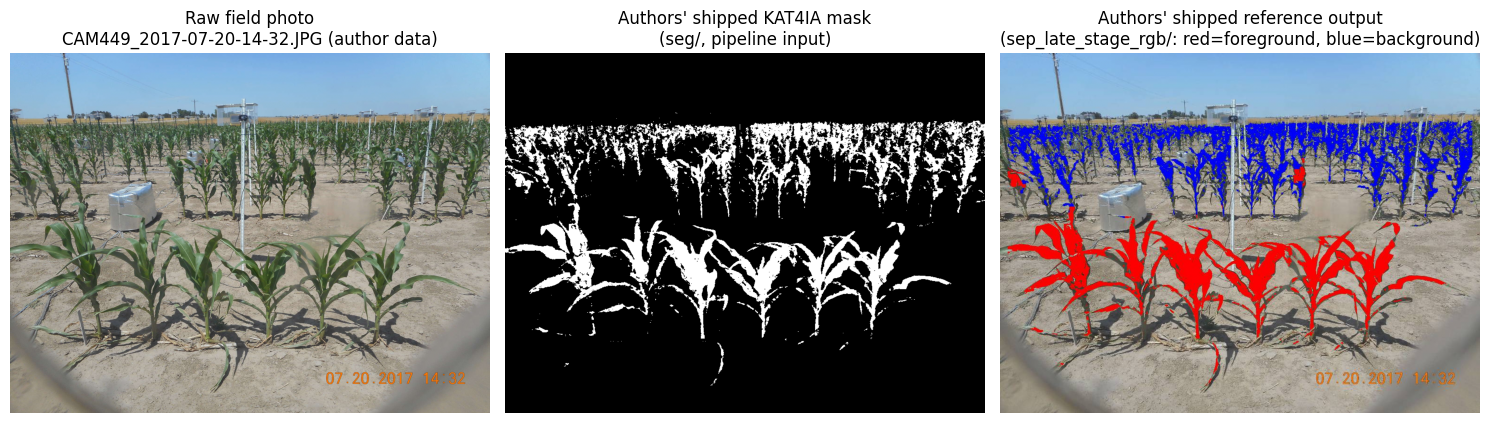

In [ ]:
import matplotlib.pyplot as plt

DEMO = "CAM449_2017-07-20-14-32.JPG"
root = "/content/Plant-Traits-Extraction-2023/plant_separation"
img = read_jpeg(f"{root}/example_plant_photos/{DEMO}")
seg = read_jpeg_bw(f"{root}/seg/{DEMO}")
ref_rgb = read_jpeg(f"{root}/sep_late_stage_rgb/{DEMO}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(img); axes[0].set_title(f"Raw field photo\n{DEMO} (author data)")
axes[1].imshow(seg, cmap="gray"); axes[1].set_title("Authors' shipped KAT4IA mask\n(seg/, pipeline input)")
axes[2].imshow(ref_rgb); axes[2].set_title("Authors' shipped reference output\n(sep_late_stage_rgb/: red=foreground, blue=background)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## Ported separation function / 分離関数のポート

The port of `testing_label_jpg` follows `plant_separation.R` (commit `e28419c`,
lines 22–110) operation by operation; the only differences are: (1) R→Python
translation, (2) `EBImage::resize` → `skimage.transform.resize` (bilinear, no
anti-aliasing), (3) `OpenImageR::superpixels` (slic, 2000, compactness 0.025) →
`skimage.segmentation.slic(n_segments=2000, compactness=0.025, convert2lab=False)`
— the SLIC implementation differs, and this parameter choice was validated
empirically against the authors' shipped reference mask (≈0.999 all-pixel
agreement on the demo photo), (4) numpy RNG with a fixed seed replaces R's
unseeded `sample()` (the authors' own pipeline is stochastic), and (5) predictions
are batched across superpixels (identical arithmetic). Red = foreground, blue =
background, matching the authors' convention.

**日本語**: `testing_label_jpg` を R のコード行に沿って翻訳します。差分は (1) 言語翻訳
(2) resize 実装 (3) SLIC 実装（著者参照マスクで経験的に検証したパラメータ）
(4) 乱数シード固定のみです。赤=前景、青=背景（著者の規約に一致）。


In [ ]:
def testing_label_jpg(img, seg, l1, l2, mlp, cut, thres, rng,
                      n_segments=2000, compactness=0.025, convert2lab=False):
    """AI-assisted Python translation of plant_separation.R testing_label_jpg
    (commit e28419c, lines 22-110). All numerical operations preserved:
      - resize raw image to seg dimensions (EBImage::resize -> skimage order=1)
      - img_1 = img * seg (background-removed image)
      - plant pixels: seg==1 in the interior [l1+1..r-l1, l2+1..c-l2] (1-based)
      - SLIC superpixels (2000, compactness as in the author call)
      - per superpixel: Z = (row <= cut); subsample floor(nn^0.75) patches for
        prediction ONLY (R lines 71-75), while ALL plant pixels of the
        superpixel receive the superpixel's label (R lines 80-91)
      - CNN predict; class2-vs-class1 comparison * Z; superpixel label =
        mean(Y_test0) > (1-thres)
      - result_bw[row,col] = 1 - label at plant pixels; result_rgb paints
        label 0 red (foreground) / label 1 blue (background), matching the
        author's shipped sep_late_stage_rgb convention.
    Runtime adaptation: predictions are batched across superpixels instead of
    one predict call per superpixel (identical arithmetic).
    """
    r, c = seg.shape
    img = ski_resize(img, (r, c), order=1, anti_aliasing=False, preserve_range=True)
    img_1 = img * seg[:, :, None]
    plant_mask = np.zeros((r, c), dtype=bool)
    plant_mask[l1:r-l1, l2:c-l2] = seg[l1:r-l1, l2:c-l2] == 1
    labels = slic(img_1 * 255.0, n_segments=n_segments, compactness=compactness,
                  convert2lab=convert2lab, channel_axis=2)
    superpixels = []
    for sid in np.unique(labels):
        rows, cols = np.nonzero(labels == sid)
        sel = plant_mask[rows, cols]
        rows, cols = rows[sel], cols[sel]      # ALL plant pixels of the superpixel
        if rows.size == 0:
            continue
        Z = (rows < cut).astype(np.float64)    # R 1-based rows <= cut == 0-based rows < cut
        if rows.size >= 10:                    # subsample the prediction set only
            idx = rng.choice(rows.size, size=int(np.floor(rows.size ** 0.75)), replace=False)
            rows_s, cols_s, Z_s = rows[idx], cols[idx], Z[idx]
        else:
            rows_s, cols_s, Z_s = rows, cols, Z
        superpixels.append((rows, cols, rows_s, cols_s, Z_s))
    all_s_rows = np.concatenate([s[2] for s in superpixels])
    all_s_cols = np.concatenate([s[3] for s in superpixels])
    all_s_Z = np.concatenate([s[4] for s in superpixels])
    patches = np.stack([img_1[rr-l1:rr+l1+1, cc-l2:cc+l2+1, :]
                        for rr, cc in zip(all_s_rows, all_s_cols)]).astype("float32")
    probs = np.concatenate([mlp.predict(patches[i:i+8192], verbose=0)
                            for i in range(0, len(patches), 8192)])
    y_test0 = (probs[:, 1] > probs[:, 0]).astype(np.float64) * all_s_Z
    bw = np.zeros((r, c))
    rgb = img_1.copy()
    off = 0
    for rows, cols, rows_s, cols_s, Z_s in superpixels:
        n = len(rows_s)                       # one prediction per sampled pixel
        label = 1 if y_test0[off:off+n].mean() > (1 - thres) else 0
        off += n
        if label == 0:
            rgb[rows, cols, :] = [1.0, 0.0, 0.0]
            bw[rows, cols] = 1.0
        else:
            rgb[rows, cols, :] = [0.0, 0.0, 1.0]
    assert off == len(y_test0)
    return bw, rgb

print("testing_label_jpg port defined")

testing_label_jpg port defined


Run the ported separation on the demo photo (author driver parameters
`l1=l2=16`, `cut=380`, `thres=0.8`) and validate it against the authors' shipped
reference mask (`sep_late_stage_bw/`): all-pixel agreement and foreground recall.
A comparison figure shows our prediction next to the authors' reference — this is
the run's primary validation evidence.

**日本語**: デモ写真にポート版分離を適用（cut=380, thres=0.8）し、著者参照マスクとの
一致率（全画素一致率と前景再現率）を検証します。


CAM449_2017-07-20-14-32.JPG: our foreground px=50660, reference foreground px=50710
all-pixel agreement=0.9986, reference-foreground recall=0.9891, 43.7s


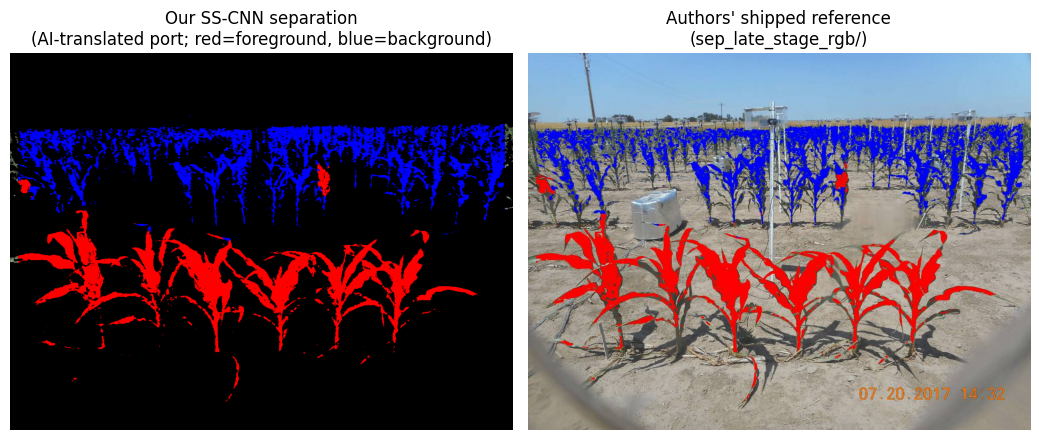

In [ ]:
import time
rng = np.random.default_rng(20231005)
t0 = time.time()
our_bw, our_rgb = testing_label_jpg(img, seg, 16, 16, mlp, 380, 0.8, rng,
                                    compactness=0.025, convert2lab=False)
dt = time.time() - t0
ref_bw = read_jpeg_bw(f"{root}/sep_late_stage_bw/{DEMO}")
agree_all = (our_bw == ref_bw).mean()
ref_fg = int((ref_bw == 1).sum())
recall_fg = ((our_bw == 1) & (ref_bw == 1)).sum() / max(ref_fg, 1)
our_fg = int((our_bw == 1).sum())
print(f"{DEMO}: our foreground px={our_fg}, reference foreground px={ref_fg}")
print(f"all-pixel agreement={agree_all:.4f}, reference-foreground recall={recall_fg:.4f}, {dt:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
axes[0].imshow(our_rgb); axes[0].set_title("Our SS-CNN separation\n(AI-translated port; red=foreground, blue=background)")
axes[1].imshow(ref_rgb); axes[1].set_title("Authors' shipped reference\n(sep_late_stage_rgb/)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## Batch separation of the 23 late-stage photos / 後期段階写真の一括分離

Run the same separation over **all photos the author pipeline processes**
(`change_ind = 29` → sorted photos 30..52), writing our foreground masks as JPEG
into `plant_separation/sep_late_stage_bw_generated/` (nothing overwritten) with the
same filenames the R height code expects. Per-photo agreement against the authors'
shipped reference masks is collected; progress is printed per photo.

**日本語**: 著者パイプラインと同じ範囲（ソート順 30..52 の 23 枚）に分離を適用し、
生成マスクを sep_late_stage_bw_generated/ に同名で保存します。各写真の参照一致率も記録します。


In [ ]:
import os, time
photo_dir = f"{root}/example_plant_photos"
photo_names = sorted(os.listdir(photo_dir))
change_ind, cut, thres, l1, l2 = 29, 380, 0.8, 16, 16  # author driver parameters
late_names = photo_names[change_ind:]  # 0-based index 29 == author's photo 30
gen_dir = "/content/Plant-Traits-Extraction-2023/plant_separation/sep_late_stage_bw_generated"
os.makedirs(gen_dir, exist_ok=True)

rng = np.random.default_rng(20231005)
per_photo, t_all = [], time.time()
for k, name in enumerate(late_names, start=1):
    t0 = time.time()
    im = read_jpeg(f"{photo_dir}/{name}")
    sg = read_jpeg_bw(f"{root}/seg/{name}")
    bw, _ = testing_label_jpg(im, sg, l1, l2, mlp, cut, thres, rng,
                              compactness=0.025, convert2lab=False)
    Image.fromarray((bw * 255).astype(np.uint8)).save(f"{gen_dir}/{name}")
    ref_path = f"{root}/sep_late_stage_bw/{name}"
    if os.path.exists(ref_path):
        ref = read_jpeg_bw(ref_path)
        per_photo.append((name, (bw == ref).mean(),
                          ((bw == 1) & (ref == 1)).sum() / max(int((ref == 1).sum()), 1)))
        print(f"[{k}/{len(late_names)}] {name}: agreement={per_photo[-1][1]:.4f} "
              f"recall={per_photo[-1][2]:.4f} ({time.time()-t0:.1f}s)", flush=True)
    else:
        per_photo.append((name, np.nan, np.nan))
        print(f"[{k}/{len(late_names)}] {name}: no reference ({time.time()-t0:.1f}s)", flush=True)
print(f"batch done in {(time.time()-t_all)/60:.1f} min")

[1/23] CAM449_2017-07-20-14-32.JPG: agreement=0.9986 recall=0.9891 (60.4s)


[2/23] CAM449_2017-07-21-08-37.JPG: agreement=0.9988 recall=0.9874 (58.9s)


[3/23] CAM449_2017-07-21-10-01.JPG: agreement=0.9989 recall=0.9956 (58.1s)


[4/23] CAM449_2017-07-21-14-55.JPG: agreement=0.9983 recall=0.9802 (46.4s)


[5/23] CAM449_2017-07-22-08-54.JPG: agreement=0.9938 recall=0.9691 (57.8s)


...

[20/23] CAM449_2017-07-29-08-20.JPG: agreement=0.9873 recall=0.9155 (68.3s)


[21/23] CAM449_2017-07-30-08-20.JPG: agreement=0.9815 recall=0.9002 (78.0s)


[22/23] CAM449_2017-07-30-13-15.JPG: agreement=0.9820 recall=0.8858 (66.3s)


[23/23] CAM449_2017-07-31-08-53.JPG: agreement=0.9869 recall=0.8734 (60.2s)


batch done in 24.1 min


## Agreement summary / 一致率の集計

Tabulate per-photo and mean agreement with the authors' shipped reference masks.
Because both the authors' pipeline and ours subsample stochastically per
superpixel, agreement below 1.0 is expected; the summary quantifies how close the
translated implementation is to the authors' own released outputs.

**日本語**: 著者参照マスクとの写真ごとの一致率を集計します。両パイプラインとも
スーパーピクセル内サブサンプリングで確率的なため、一致率 1.0 にはなりません。


In [ ]:
import pandas as pd
agree_df = pd.DataFrame(per_photo, columns=["photo", "all_pixel_agreement", "ref_foreground_recall"])
agree_df["photo"] = (agree_df["photo"].str.replace("CAM449_", "", regex=False)
                                   .str.replace(".JPG", "", regex=False))
print(agree_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print(f"mean all-pixel agreement: {agree_df.all_pixel_agreement.mean():.4f}")
print(f"mean reference-foreground recall: {agree_df.ref_foreground_recall.mean():.4f}")

           photo  all_pixel_agreement  ref_foreground_recall
2017-07-20-14-32               0.9986                 0.9891
2017-07-21-08-37               0.9988                 0.9874
2017-07-21-10-01               0.9989                 0.9956
2017-07-21-14-55               0.9983                 0.9802
2017-07-22-08-54               0.9938                 0.9691
2017-07-22-17-13               0.9973                 0.9773
2017-07-23-08-00               0.9973                 0.9820
2017-07-23-09-10               0.9969                 0.9791
2017-07-23-11-05               0.9978                 0.9806
2017-07-24-08-00               0.9924                 0.9460
2017-07-24-11-50               0.9972                 0.9903
2017-07-25-08-00               0.9872                 0.8990
2017-07-25-13-47               0.9967                 0.9760
2017-07-25-17-40               0.9899                 0.9510
2017-07-26-08-00               0.9921                 0.9564
2017-07-26-13-25        

## Height extraction & growth curves with the authors' R code / 著者 R コードによる高さ抽出と成長曲線

Write two R driver scripts for the authors' pinned code: the main driver runs
`height_measure_seq` on the shipped `seg/` masks (early-stage heights + change-point
detection), `height_measure_late_seq` on **our generated** late-stage masks, and the
growth-curve assembly from `growth_curve_est.R` (smoothed spline + outlier rule
`C=2.5` + nondecreasing `monreg0`); the reference driver recomputes late heights
from the **authors' shipped** masks for comparison. The computation lines are
replicated verbatim from `growth_curve_est.R`; the only changes are the `path_sep`
assignment (pointing at our generated masks) and saving outputs (CSV + the authors'
ggplot via `ggsave`). Heights are in **pixels** (the author code defines no cm
calibration).

**日本語**: 著者の R スクリプトを実行する 2 つのドライバを書き込みます。seg/ から前期
高さと変化点、生成マスクから後期高さを抽出し、growth_curve_est.R の手順（平滑化スプライン+
外れ値除去+単調回帰）で成長曲線を推定します。参照用ドライバは著者マスクから後期高さを
再計算します。計算行は growth_curve_est.R からの逐語複製で、変更は path_sep の指定と
出力保存のみです。単位はピクセルです。


In [ ]:
from pathlib import Path

R_DRIVER = r'''Sys.setenv(TZ = "America/Chicago")
setwd("/content/Plant-Traits-Extraction-2023")
cat(R.version.string, "\n")
source("height_measurement/early_height_measure.R")
source("height_measurement/late_height_measure.R")

## ---- monotone spline regression + outlier rule, copied VERBATIM from
##      height_measurement/growth_curve_est.R lines 10-55 (the driver does not
##      source() that file because its hardcoded path_sep would override ours) ----
monreg0 <- function(x, y, df=4, plot_it = FALSE){
  x <- as.numeric(x)
  N <- length(x)
  b <- max(x)
  a <- min(x)
  x <- (x-a)/(b-a)
  fit <- smooth.spline(x, y, df = df)
  pts <- (1:N)/N
  mu0 <- predict(fit, newdata = data.frame(pts))$y
  mu0_diff <- mu0[-1] - mu0[-N]
  use_monreg <- any(mu0_diff < 0)
  if (use_monreg){
    d <- density(mu0, kernel = "gaussian", n=1e4)
    t <- d$x
    delta <- t[2]-t[1]
    pdf <- d$y
    cdf <- cumsum(pdf) * delta
    out <- rep(0, N)
    for (i in 1:N){
      ind <- which.min(abs(cdf-x[i]))
      out[i] <- t[ind]
    }
  } else {
    out <- predict(fit, newdata = data.frame(x))$y
  }
  if (plot_it == TRUE){
    plot(x, y)
    lines(fit, col = "red")
    if (use_monreg){
      lines(x, out, col = "blue")
    }
  }
  return(out)
}

outlier_detect <- function(resid, C){
  q1 <- quantile(resid, 0.25)
  q3 <- quantile(resid, 0.75)
  iqr <- q3 - q1
  lb <- q1 - C * iqr
  ub <- q3 + C * iqr
  outlier <-  (resid < lb) | (resid > ub)
  return(outlier)
}

## ---- author calls from growth_curve_est.R (verbatim paths/parameters;
##      path_sep points to OUR generated masks) ----
path_seg <- "plant_separation/seg"
xx <- height_measure_seq(path_seg, cr10=0.1, cr11=0.025, cr12=0.075, sep1=10,
                         p = 2, cr20 = 0.2, sep2 = 50, cr31=0.1, cr32=0.1,
                         cr3=0.025)
cat("K =", xx$K, " change_ind =", xx$change_ind, " cut =", xx$cut, "\n")

path_sep <- "plant_separation/sep_late_stage_bw_generated"
xx1 <- height_measure_late_seq(path_sep, K=xx$K, cr11=0.075, cr12=0.025,
                               p = 2, cr20 = 0.4, sep = 30, cr31=0.15, cr32=0.15,
                               cr33=0.025, cr34=0.01)

## ---- growth-curve assembly, replicated verbatim from growth_curve_est.R
##      lines 77-108 ----
DD <- NULL
for (i in 1:xx$K){
  dd1 <- data.frame(time = xx$time,
                    height = xx$height_early[i,],
                    stage = rep("early", length(xx$time)),
                    pos = rep(i, length(xx$time)))
  time1 <- xx1$time[xx1$time < "2017-08-10 08:00:00 CDT"]
  height_late1 <- xx1$height_late[,xx1$time < "2017-08-10 08:00:00 CDT"]
  dd2 <- data.frame(time = time1,
                    height = height_late1[i,],
                    stage = rep("late", length(time1)),
                    pos = rep(i, length(time1)))
  dd <- rbind(dd1, dd2)
  x <- dd$time
  y <- dd$height
  na_idx <- is.na(y)
  x <- x[!na_idx]
  y <- y[!na_idx]
  fit <- smooth.spline(x, y, df = 4.5)
  yhat <- predict(fit, newdata = data.frame(x))$y
  resid <- y - yhat
  outlier <- outlier_detect(resid, 2.5)
  x1 <- x[!outlier]
  y1 <- y[!outlier]
  yhat1 <- monreg0(x1, y1, df=4.5, plot_it = FALSE)
  idx_use <- {(!na_idx) & (!outlier)}
  dd <- data.frame(dd[idx_use,], curve = yhat1)
  DD <- rbind(DD, dd)
}
DD$pos <- as.factor(DD$pos)
write.csv(DD, "/content/DD_growth_curves.csv", row.names = FALSE)
cat("DD rows:", nrow(DD), " plants:", nlevels(DD$pos), "\n")

## ---- author ggplot (growth_curve_est.R lines 115-122), saved to PNG ----
library(ggplot2)
p <- ggplot(data=DD) +
  geom_point(aes(x = time, y = height, colour = stage), size = 0.8) +
  geom_line(aes(x = time, y = curve), size = 1.1) +
  facet_wrap(~pos, nrow=2) +
  xlab("Date") +
  ylab("Height (pixels)") +
  theme_bw(base_size = 14) +
  guides(fill=guide_legend(title="Stage"))
ggsave("/content/growth_curves.png", p, width = 12, height = 6, dpi = 110)
cat("growth_curves.png written\n")'''
Path("/content/height_driver.R").write_text(R_DRIVER)

R_REFERENCE = r'''Sys.setenv(TZ = "America/Chicago")
setwd("/content/Plant-Traits-Extraction-2023")
source("height_measurement/early_height_measure.R")
source("height_measurement/late_height_measure.R")
xx <- height_measure_seq("plant_separation/seg", cr10=0.1, cr11=0.025, cr12=0.075,
                         sep1=10, p=2, cr20=0.2, sep2=50, cr31=0.1, cr32=0.1, cr3=0.025)
xx1 <- height_measure_late_seq("plant_separation/sep_late_stage_bw", K=xx$K,
                               cr11=0.075, cr12=0.025, p=2, cr20=0.4, sep=30,
                               cr31=0.15, cr32=0.15, cr33=0.025, cr34=0.01)
time1 <- xx1$time[xx1$time < "2017-08-10 08:00:00 CDT"]
height_late1 <- xx1$height_late[,xx1$time < "2017-08-10 08:00:00 CDT"]
write.csv(data.frame(time=format(time1, "%Y-%m-%d %H:%M:%S"), t(height_late1)),
          "/content/late_heights_reference_masks.csv", row.names=FALSE)
cat("reference-mask late heights written\n")'''
Path("/content/height_driver_reference.R").write_text(R_REFERENCE)

print("driver scripts written")

driver scripts written


Run both R drivers and stream their output. The main driver prints `K` (number of
foreground plants detected), the change-point index and cutoff derived from the
authors' change-point method, and writes `/content/DD_growth_curves.csv` +
`/content/growth_curves.png`.

**日本語**: 2 つの R ドライバを実行し、出力を表示します。K（前景植物体数）、
変化点インデックス、cut 値が表示され、CSV と PNG が生成されます。


In [ ]:
import subprocess, time
for script in ["/content/height_driver.R", "/content/height_driver_reference.R"]:
    t0 = time.time()
    r = subprocess.run(["Rscript", script], capture_output=True, text=True, timeout=2400)
    print(f"--- {script} (exit {r.returncode}, {time.time()-t0:.0f}s) ---")
    print(r.stdout)
    if r.returncode != 0:
        print(r.stderr[-3000:])
        raise RuntimeError(f"R driver failed: {script}")

--- /content/height_driver.R (exit 0, 11s) ---
R version 4.6.1 (2026-06-24) 
K = 6  change_ind = 0 1 2 4 8 9 10 11 12 13 14 15 16 17 18 23 25 26 27 29 31 32 34 36 37 39 40 42 43 44 46 47 49 50  cut = 494 
DD rows: 78  plants: 6 
growth_curves.png written



--- /content/height_driver_reference.R (exit 0, 9s) ---
reference-mask late heights written



## Results: growth curves / 結果: 成長曲線

Recreate the authors' ggplot figure from the CSV produced with **our** separated
masks. Each facet position is one foreground plant: dots are per-photo pixel heights
(early = KAT4IA masks, late = our SS-CNN masks), the line is the paper's
nondecreasing fitted growth curve. This graph is an additional visualization created
for this notebook, matching the authors' figure content.

**日本語**: 私たちの分離マスクから得た CSV で著者の ggplot 図を再現します。
各位置が 1 植物体で、点は写真ごとのピクセル高さ（前期=KAT4IA マスク、後期=SS-CNN マスク）、
線は論文の単調成長曲線です。


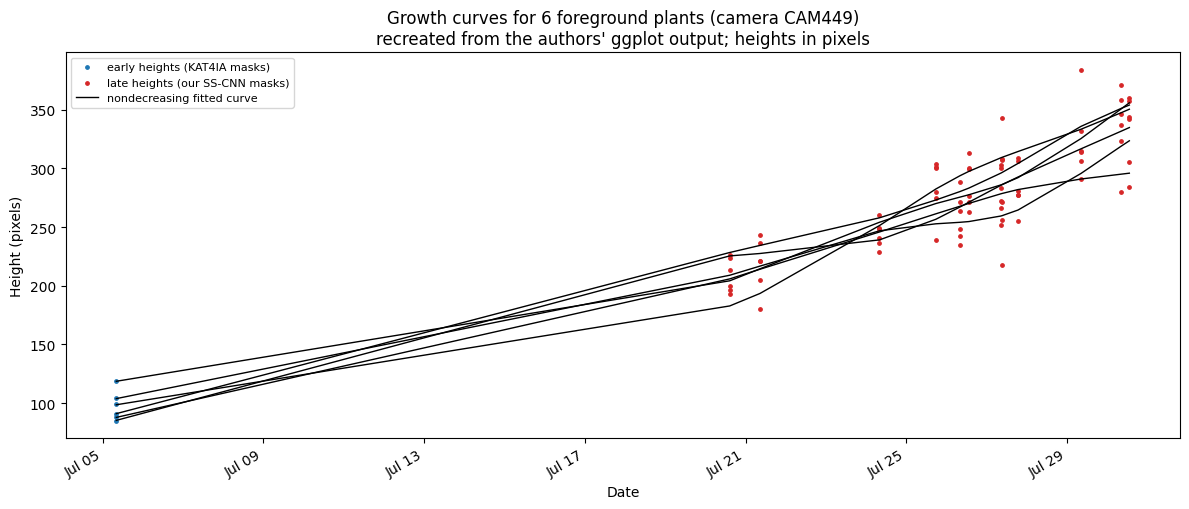

       count  min  max
stage                 
early      6   85  119
late      72  180  384


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DD = pd.read_csv("/content/DD_growth_curves.csv", parse_dates=["time"])
n_plants = DD["pos"].nunique()
fig, ax = plt.subplots(figsize=(12, 2.6 * ((n_plants + 3) // 4)))
stage_colors = {"early": "#1f77b4", "late": "#d62728"}
for pos, grp in DD.groupby("pos"):
    sub = grp.sort_values("time")
    for stage, pts in sub.groupby("stage"):
        label = {"early": "early heights (KAT4IA masks)",
                 "late": "late heights (our SS-CNN masks)"}.get(stage) if pos == 1 else None
        ax.scatter(pts["time"], pts["height"], s=6, color=stage_colors[stage], label=label)
    ax.plot(sub["time"], sub["curve"], color="black", lw=1.0,
            label="nondecreasing fitted curve" if pos == 1 else None)
ax.set_xlabel("Date"); ax.set_ylabel("Height (pixels)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(loc="best", fontsize=8)
ax.set_title(f"Growth curves for {n_plants} foreground plants (camera CAM449)\nrecreated from the authors' ggplot output; heights in pixels")
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

print(DD.groupby("stage")["height"].agg(["count", "min", "max"]).to_string())

### Validation: our masks vs the authors' masks on final heights / 検証: 生成マスクと著者マスクの高さ比較

Compare late-stage pixel heights extracted from **our** generated masks against
heights from the **authors' shipped** masks (same pinned R code): correlation, mean
absolute difference, and a scatter plot. This closes the loop from CNN translation
to the paper's measurement.

**日本語**: 生成マスクと著者提供マスクから同じ R コードで抽出した後期高さを比較します
（相関・平均絶対差・散布図）。


paired late-height points: 72 of 72 | correlation=0.9570 | mean |diff|=8.72 px


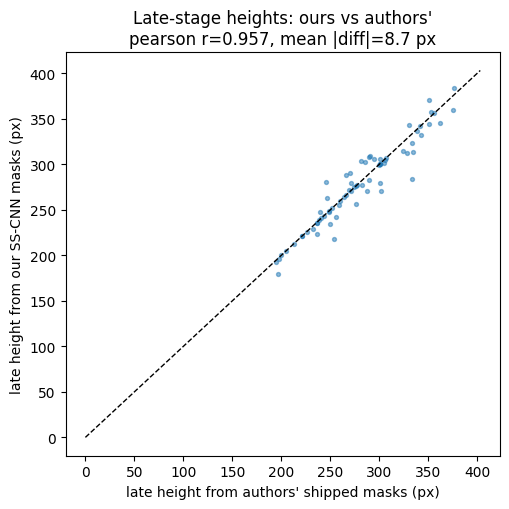

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ref = pd.read_csv("/content/late_heights_reference_masks.csv")
our = DD[DD.stage == "late"].copy()
our["pos_i"] = our["pos"].astype(int)
our_wide = our.pivot_table(index="pos_i", columns="time", values="height")
our_wide.columns = pd.to_datetime(our_wide.columns).strftime("%Y-%m-%d %H:%M:%S")
common_times = [t for t in ref["time"] if t in set(our_wide.columns)]
ref_m = ref.set_index("time").loc[common_times].to_numpy(dtype=float).T  # plants x times
our_m = our_wide[common_times].to_numpy(dtype=float)
assert ref_m.shape == our_m.shape

ref_v = ref_m.ravel(); our_v = our_m.ravel()
ok = ~(np.isnan(ref_v) | np.isnan(our_v))
corr = np.corrcoef(ref_v[ok], our_v[ok])[0, 1]
mad = np.mean(np.abs(ref_v[ok] - our_v[ok]))
print(f"paired late-height points: {ok.sum()} of {ref_v.size} | correlation={corr:.4f} | mean |diff|={mad:.2f} px")

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(ref_v[ok], our_v[ok], s=8, alpha=0.5)
lim = (0, max(np.nanmax(ref_v), np.nanmax(our_v)) * 1.05)
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("late height from authors' shipped masks (px)")
ax.set_ylabel("late height from our SS-CNN masks (px)")
ax.set_title(f"Late-stage heights: ours vs authors'\npearson r={corr:.3f}, mean |diff|={mad:.1f} px")
fig.tight_layout(); plt.show()

## Interpretation, differences, validation record / 解釈と差分、検証記録

**What was executed**: the released SS-CNN (`SS_CNN.hdf5`) separated foreground from
background plant pixels in the 23 late-stage photos of the authors' example sequence
using their parameters (`cut=380`, `thres=0.8`, 33×33 patches, 2000 SLIC
superpixels), then the authors' unmodified R code extracted early/late pixel heights
and fitted nondecreasing growth curves. The paper's Methods pipeline for one
camera's example sequence is thereby exercised end-to-end on the released example
data, except the steps listed as out of scope in the opening cell.

**Differences from the paper**: (1) the CNN stage runs as an AI-assisted
Python/TensorFlow translation instead of R Keras — the released legacy-H5 weights
are loaded unchanged, and agreement is measured against the authors' own shipped
outputs (table above); (2) SLIC implementations differ (empirically validated
parameter choice); (3) heights are pixel units with no cm conversion (none exists in
the released code); (4) the self-supervised training stage, KAT4IA re-segmentation,
and FPCA genotype analysis are not executed (released weights are used
inference-first; FPCA code is not released).

**Validation record**: all inputs verified by Git blob SHA-1 at the pinned commit;
separation outputs compared to the authors' shipped `sep_late_stage_*` masks;
late-stage heights from our masks compared to heights from the authors' masks via
the same pinned R measurement code. One-example demonstration — this does not
reproduce the paper's dataset-level results, and the paper reports no ground-truth
heights for this experiment.

**日本語**: 実行した内容、論文との差分（R→Python 翻訳、SLIC 実装差、ピクセル単位、
未実施ステップ）、検証記録（blob SHA-1 検証、参照マスク一致率、高さ比較）をまとめます。

**References**: paper DOI 10.34133/plantphenomics.0052; author code and data
`github.com/xingcheg/Plant-Traits-Extraction-2023` @
`e28419c916935e4a9cacb3502e83341e5b9009a3` (retrieved 2026-10-07). Prior research
guidance: PhenoPaper investigation
`p-9509ca4adeb1b05d75ea813b28d6a667-20260930T040544Z-3245204` (AI-generated, unverified).
